# FactoryIO
### 무게측정, 스케일 + 펄스기법, csv 저장
### modbus_weight01 대상

In [ ]:
# !pip install pymodbus

In [49]:
from pymodbus.client import ModbusTcpClient
import time as tt
import threading

client = ModbusTcpClient('210.119.14.74', port=502)
client.connect()

True

![스크린샷 2026-07-14 091317.png](<attachment:스크린샷 2026-07-14 091317.png>)
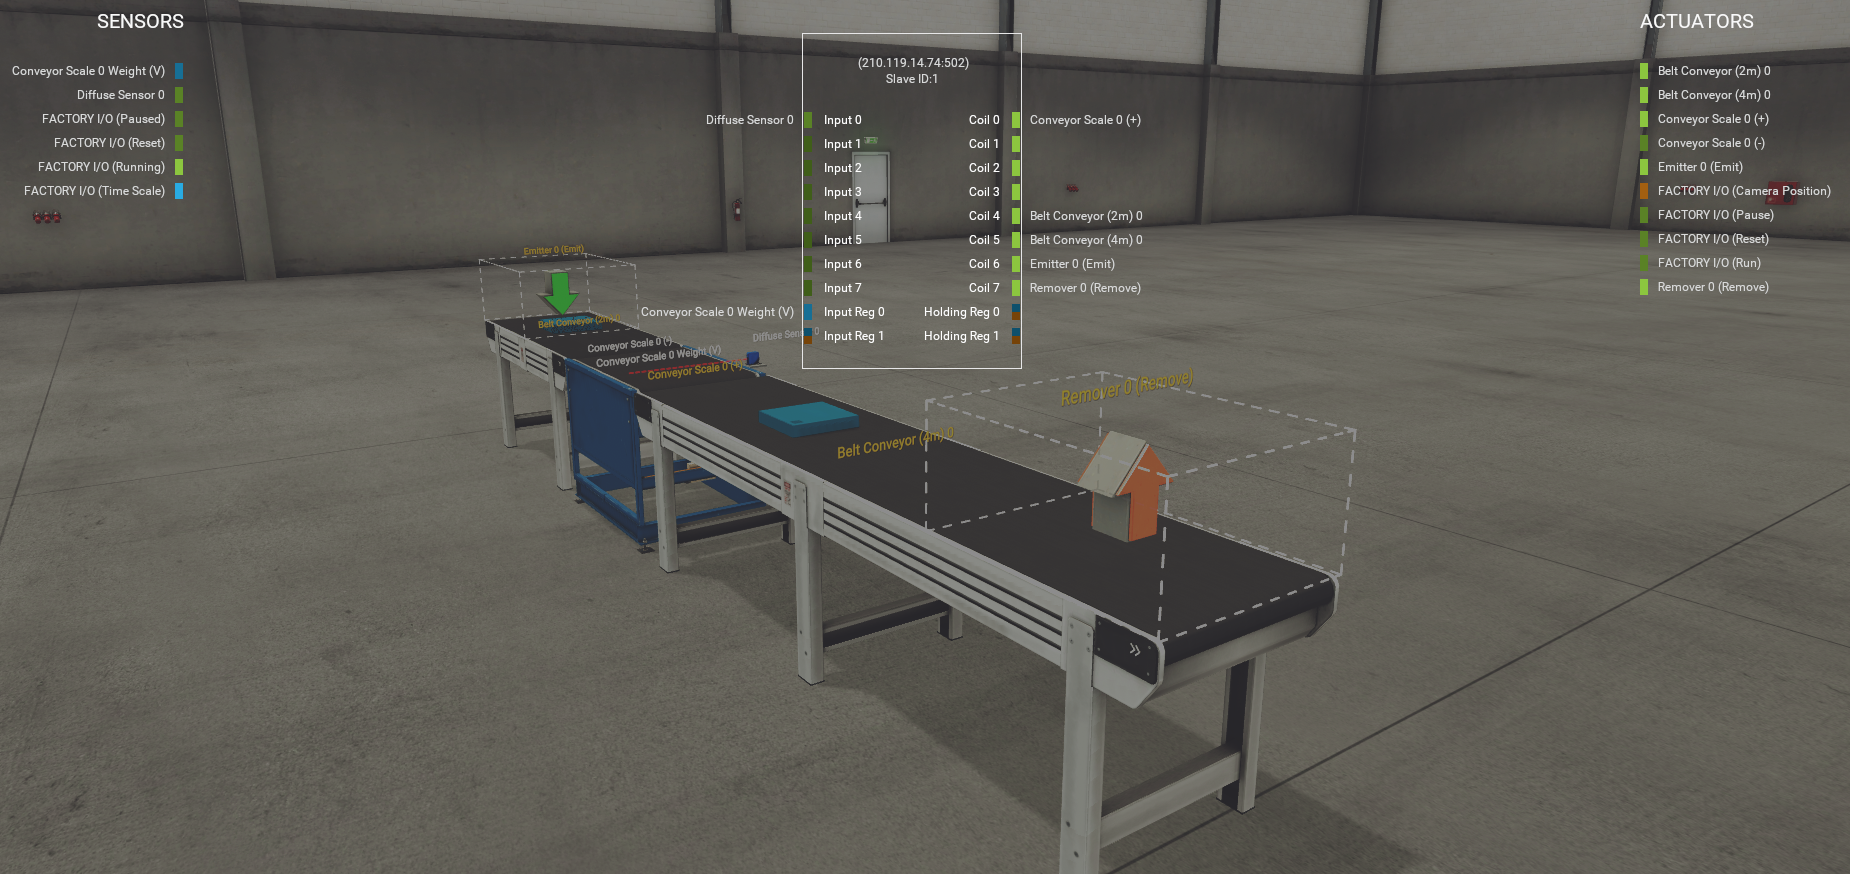

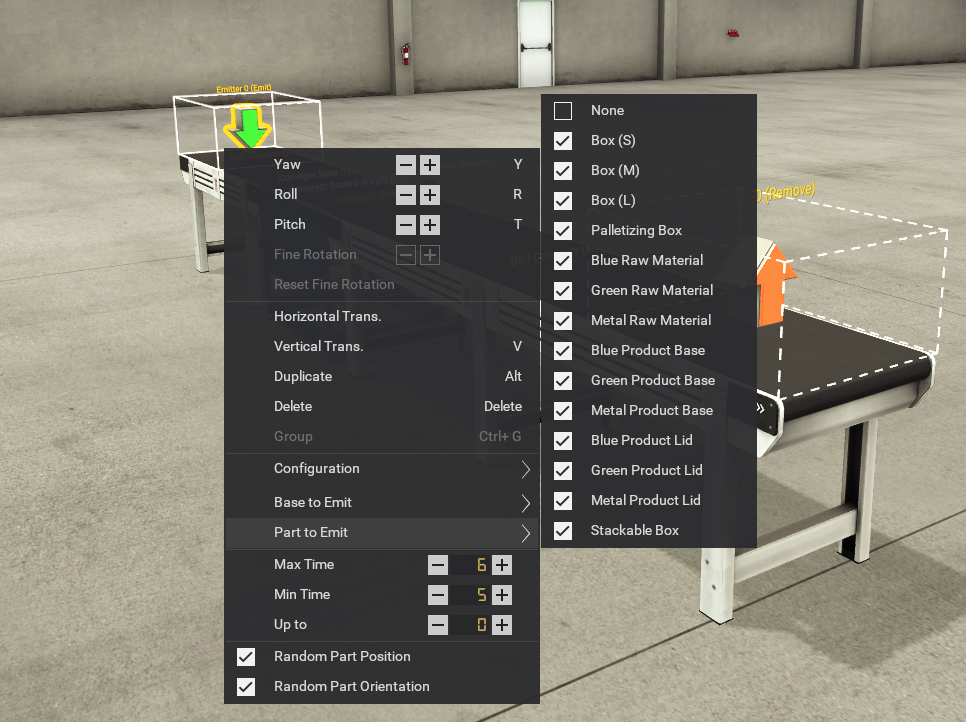

In [50]:
# 초기화
client.write_coils(0, [0]*8 )

In [51]:
# 켜야되는 출력 4부터 4개 모두 On
client.write_coils(0, [1]*8 )

In [ ]:
# csv 로 저장
import csv
from datetime import datetime
import os

scan_run = Trues
state = {"prev": False}

def sensor_scan():

    new_file = not os.path.exists("work/weight_log.csv") # 본인의 커널 경로에 맞게 설정하기 , 지금은 컨테이너의 jovyan 내에

    log = open("work/weight_log.csv", "a", newline="", encoding="utf-8")
    writer = csv.writer(log)

    if new_file:
        writer.writerow(["시간", "무게(kg)"])

    while scan_run:
        sensor = client.read_discrete_inputs(0, count=1).bits[0]

        # 상승 에지(0 → 1) 검출
        if sensor and not state["prev"]:
            client.write_coil(0, 0)
            tt.sleep(0.7)

            weight = client.read_input_registers(0, count=1).registers
            kg = (weight[0] * 2) / 100

            # CSV 저장
            writer.writerow([
                datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                kg
            ])
            log.flush()

            print(f"{kg:.2f} Kg")

            client.write_coil(0, 1)

        state["prev"] = sensor
        tt.sleep(0.1)
    log.close()
# 스레드 시작
th_sensor = threading.Thread(target=sensor_scan, daemon=True)
th_sensor.start()

In [ ]:
# 스레드 정지
scan_run = False

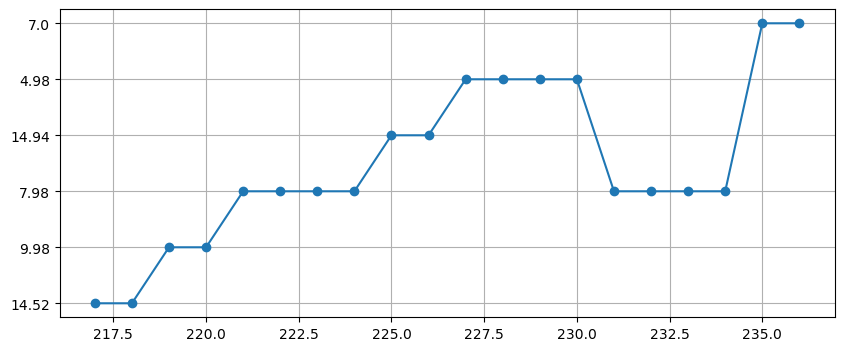

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
df = pd.read_csv("work/weight_log.csv")
df = df.tail(20)
plt.figure(figsize=(10,4))
plt.plot(df["무게(kg)"], "-o")
plt.grid(True)
plt.show()
# 호출할때마다 보여줌, 실시간으로 가능하나 실무적인 실시간은 SCADA 에 맡긴다.

In [48]:
!pwd

/home/jovyan
